# Compute PSD — Case Study 2
Calcola la Power Spectral Density (PSD) da file `.fif` epocati per tutti i soggetti.
Output: matrice `[n_soggetti x n_canali x n_frequenze]` in formato `.npy` e `.mat`.

## 0. Import

In [5]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.io import savemat

mne.set_log_level('WARNING')
print('Libraries loaded OK')

Libraries loaded OK


## 1. CONFIG
**Modifica solo questa cella** prima di eseguire il resto.

In [6]:
# ── Paths ──────────────────────────────────────────────────────
DATA_DIR     = "/Users/Altair93/Documents/Dottorato/PATHS/OLD/Original_data/"
FILE_PATTERN = "*_interpolated-epo.fif"
OUTPUT_DIR   = "/Users/Altair93/Documents/TNFP/ONDA Lab/Projects/tutorial_EEG-NPSI/PSD/"

# ── PSD parameters ─────────────────────────────────────────────
FMIN      = 1.0   # Hz — lower bound of freq range
FMAX      = 40.0  # Hz — upper bound of freq range
N_OVERLAP = 0     # Welch overlap (samples); 0 = no overlap
# n_fft is computed automatically from the shortest epoch (see Step 2)

# ── Canonical frequency bands (for QC summary table) ───────────
BANDS = {
    "delta": (1.0,  4.0),
    "theta": (4.0,  8.0),
    "alpha": (8.0,  13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 40.0),
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output folder: {OUTPUT_DIR}")

Output folder: /Users/Altair93/Documents/TNFP/ONDA Lab/Projects/tutorial_EEG-NPSI/PSD/


## 2. Pre-scansione: lunghezza epoche e calcolo n_fft
Prima di calcolare le PSD, scansioniamo tutti i file per trovare la lunghezza minima delle epoche.  
`n_fft` viene fissato **una volta sola** come la più grande potenza di 2 ≤ epoca più corta.  
Questo garantisce che tutti i soggetti abbiano la **stessa griglia frequenziale**.

In [7]:
files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_PATTERN)))
if not files:
    raise FileNotFoundError(f'Nessun file trovato in {DATA_DIR} con pattern {FILE_PATTERN}')
print(f'File trovati: {len(files)}\n')

# pre-scansione: legge solo i metadati (no preload) per ogni soggetto
info_rows = []
for f in files:
    sub   = os.path.basename(f).split('_')[0]
    epo   = mne.read_epochs(f, preload=False, verbose=False)
    n     = len(epo.times)
    sfreq = epo.info['sfreq']
    info_rows.append({'subject_id': sub, 'n_times': n, 'sfreq': sfreq})
    print(f'  {sub}: {n} campioni  ({n/sfreq:.2f} s)  @ {sfreq} Hz')

df_info   = pd.DataFrame(info_rows)
min_times = int(df_info['n_times'].min())
sfreq     = float(df_info['sfreq'].iloc[0])

# strategia: usiamo n_per_seg = largest power of 2 <= shortest epoch
# Welch frammenta ogni epoca in segmenti di questa lunghezza.
# Tutti i soggetti producono la stessa griglia frequenziale
# indipendentemente dalla lunghezza dell'epoca originale.
n_per_seg = int(2 ** np.floor(np.log2(min_times)))
n_fft     = n_per_seg   # n_fft = n_per_seg e' la scelta standard
freq_res  = sfreq / n_fft

print(f'\nLunghezze epoche trovate:')
for n, count in df_info['n_times'].value_counts().sort_index().items():
    print(f'  {n} campioni ({n/sfreq:.2f} s): {count} soggetti')

print(f'\nEpoca piu corta : {min_times} campioni')
print(f'n_per_seg       : {n_per_seg}  (Welch segment length)')
print(f'n_fft           : {n_fft}')
print(f'Risoluzione freq: {freq_res:.4f} Hz')
print(f'Range freq      : {FMIN}-{FMAX} Hz')
print(f'\nTutti i soggetti produrranno la stessa griglia frequenziale.')
print(f'Le epoche piu lunghe verranno suddivise in segmenti da {n_per_seg} campioni')
print(f'e la PSD sara mediata su di essi (comportamento standard di Welch).')

df_info.to_csv(os.path.join(OUTPUT_DIR, 'QC_epoch_lengths.csv'), index=False)
print('\nSalvato: QC_epoch_lengths.csv')


File trovati: 40

  sub-104: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-105: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-106: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-107: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-108: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-109: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-110: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-111: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-112: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-113: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-114: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-118: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-119: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-120: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-122: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-123: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-124: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-125: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-127: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-128: 1251 campioni  (5.00 s)  @ 250.0 Hz
  sub-129: 1251 campioni  (5.00 s)  @ 250.

## 3. Calcolo PSD (Welch) per tutti i soggetti

In [8]:
def compute_band_power(psd_2d, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return float(psd_2d[:, mask].mean())

psd_list      = []
subject_ids   = []
channel_names = None
freq_axis     = None
summary_rows  = []
skipped       = []

print(f'n_fft={n_fft}, n_per_seg={n_per_seg} — fissi per tutti i soggetti\n')

for f in files:
    sub = os.path.basename(f).split('_')[0]
    print(f'  {sub} ...', end=' ', flush=True)

    epo = mne.read_epochs(f, preload=True, verbose=False)
    epo.pick_types(eeg=True, verbose=False)

    if channel_names is not None and list(epo.ch_names) != channel_names:
        print(f'SKIP (canali: {len(epo.ch_names)} vs attesi {len(channel_names)})')
        skipped.append(sub)
        continue

    # n_per_seg garantisce segmenti di lunghezza fissa indipendentemente
    # dalla durata dell'epoca: epoche lunghe vengono spezzate in piu segmenti,
    # epoche corte usano un segmento solo. La freq axis e' sempre identica.
    spec = epo.compute_psd(
        method='welch',
        fmin=FMIN, fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=N_OVERLAP,
        verbose=False
    )

    psds  = spec.get_data()       # [n_epoche, n_ch, n_freqs]
    freqs = spec.freqs
    pmean = psds.mean(axis=0)     # [n_ch, n_freqs]

    # verifica freq axis
    if freq_axis is None:
        freq_axis = freqs
    elif len(freqs) != len(freq_axis):
        print(f'SKIP (freq axis: {len(freqs)} bin vs attesi {len(freq_axis)})')
        skipped.append(sub)
        continue

    psd_list.append(pmean)
    subject_ids.append(sub)
    if channel_names is None:
        channel_names = list(spec.ch_names)

    total_power = float(pmean.mean())
    print(f'OK  [{psds.shape[0]} epoche | mean power {total_power:.3e}]')

    row = {'subject_id': sub, 'n_epochs': psds.shape[0],
           'n_times': len(epo.times), 'mean_power': total_power}
    for bname, (blo, bhi) in BANDS.items():
        row[f'{bname}_power'] = compute_band_power(pmean, freqs, blo, bhi)
    summary_rows.append(row)

if skipped:
    print(f'\nSoggetti saltati: {skipped}')
print(f'\nSoggetti processati con successo: {len(psd_list)}')


n_fft=1024, n_per_seg=1024 — fissi per tutti i soggetti

  sub-104 ... OK  [67 epoche | mean power 1.216e-13]
  sub-105 ... OK  [65 epoche | mean power 4.885e-13]
  sub-106 ... OK  [80 epoche | mean power 5.773e-13]
  sub-107 ... OK  [111 epoche | mean power 9.376e-13]
  sub-108 ... OK  [53 epoche | mean power 1.102e-13]
  sub-109 ... OK  [63 epoche | mean power 2.287e-13]
  sub-110 ... OK  [37 epoche | mean power 7.102e-13]
  sub-111 ... OK  [66 epoche | mean power 8.612e-13]
  sub-112 ... OK  [66 epoche | mean power 4.856e-13]
  sub-113 ... OK  [56 epoche | mean power 4.344e-13]
  sub-114 ... OK  [108 epoche | mean power 6.719e-13]
  sub-118 ... OK  [76 epoche | mean power 3.153e-12]
  sub-119 ... OK  [78 epoche | mean power 1.060e-12]
  sub-120 ... OK  [69 epoche | mean power 3.388e-13]
  sub-122 ... OK  [67 epoche | mean power 6.997e-13]
  sub-123 ... OK  [77 epoche | mean power 9.531e-13]
  sub-124 ... OK  [68 epoche | mean power 7.367e-13]
  sub-125 ... OK  [74 epoche | mean powe

## 4. Assembla matrice finale e log-transform

In [9]:
# verifica che tutte le array abbiano la stessa shape
shapes = set(a.shape for a in psd_list)
if len(shapes) > 1:
    raise ValueError(
        f"Shape inconsistenti: {shapes}\n"
        "Verifica che tutti i soggetti abbiano lo stesso numero di canali EEG."
    )

psd_matrix     = np.stack(psd_list, axis=0)   # [n_subj, n_ch, n_freqs]
psd_log_matrix = np.log10(psd_matrix)

print(f"Shape matrice PSD : {psd_matrix.shape}")
print(f"  soggetti        : {psd_matrix.shape[0]}")
print(f"  canali          : {psd_matrix.shape[1]}")
print(f"  bin freq        : {psd_matrix.shape[2]}")
print(f"  range freq      : {freq_axis[0]:.2f}–{freq_axis[-1]:.2f} Hz")
print(f"  risoluzione     : {np.diff(freq_axis).mean():.4f} Hz")

Shape matrice PSD : (40, 204, 159)
  soggetti        : 40
  canali          : 204
  bin freq        : 159
  range freq      : 1.22–39.79 Hz
  risoluzione     : 0.2441 Hz


## 5. Salvataggio output

In [12]:
# ── Salvataggio: un file per soggetto + matrice globale ────────

# cartella per i file individuali
per_sub_dir = os.path.join(OUTPUT_DIR, 'per_subject')
os.makedirs(per_sub_dir, exist_ok=True)

# ── 1. file individuali ─────────────────────────────────────────
print('Salvataggio file per soggetto...')
for i, sub in enumerate(subject_ids):

    psd_sub     = psd_list[i]              # [n_ch, n_freqs]
    psd_log_sub = np.log10(psd_list[i])    # [n_ch, n_freqs]

    # numpy: un .npz per soggetto (contiene psd, psd_log, freq_axis, ch_names)
    np.savez(
        os.path.join(per_sub_dir, f'{sub}_psd.npz'),
        psd         = psd_sub,
        psd_log     = psd_log_sub,
        freq_axis   = freq_axis,
        channel_names = np.array(channel_names, dtype=object)
    )

    # MATLAB: un .mat per soggetto
    savemat(
        os.path.join(per_sub_dir, f'{sub}_psd.mat'),
        {
            'psd'           : psd_sub,
            'psd_log'       : psd_log_sub,
            'freq_axis'     : freq_axis,
            'channel_names' : np.array(channel_names, dtype=object),
            'subject_id'    : sub,
            'n_fft'         : float(n_fft),
            'n_per_seg'     : float(n_per_seg),
            'sfreq'         : sfreq,
            'fmin'          : FMIN,
            'fmax'          : FMAX,
        }
    )
    print(f'  {sub} -> {sub}_psd.npz / {sub}_psd.mat')

print(f'\nSalvati {len(subject_ids)} file individuali in: {per_sub_dir}')

# ── 2. matrice globale (per analisi di gruppo) ──────────────────
print('\nAssemblo matrice globale...')
psd_matrix     = np.stack(psd_list, axis=0)    # [n_subj, n_ch, n_freqs]
psd_log_matrix = np.log10(psd_matrix)

print(f'Shape matrice: {psd_matrix.shape}')
print(f'  soggetti  : {psd_matrix.shape[0]}')
print(f'  canali    : {psd_matrix.shape[1]}')
print(f'  freq bins : {psd_matrix.shape[2]}')
print(f'  freq range: {freq_axis[0]:.2f}-{freq_axis[-1]:.2f} Hz')
print(f'  freq res  : {np.diff(freq_axis).mean():.4f} Hz')

# numpy
np.save(os.path.join(OUTPUT_DIR, 'psd_matrix.npy'),     psd_matrix)
np.save(os.path.join(OUTPUT_DIR, 'psd_log_matrix.npy'), psd_log_matrix)
np.save(os.path.join(OUTPUT_DIR, 'freq_axis.npy'),       freq_axis)

# MATLAB globale
savemat(os.path.join(OUTPUT_DIR, 'psd_data_CS2.mat'), {
    'psd_matrix'    : psd_matrix,
    'psd_log_matrix': psd_log_matrix,
    'freq_axis'     : freq_axis,
    'subject_ids'   : np.array(subject_ids,   dtype=object),
    'channel_names' : np.array(channel_names, dtype=object),
    'n_fft'         : float(n_fft),
    'n_per_seg'     : float(n_per_seg),
    'sfreq'         : sfreq,
    'fmin'          : FMIN,
    'fmax'          : FMAX,
})

# testo
with open(os.path.join(OUTPUT_DIR, 'channel_names.txt'), 'w') as fh:
    fh.write('\n'.join(channel_names))
with open(os.path.join(OUTPUT_DIR, 'subject_ids.txt'), 'w') as fh:
    fh.write('\n'.join(subject_ids))

# summary CSV
pd.DataFrame(summary_rows).to_csv(
    os.path.join(OUTPUT_DIR, 'psd_summary.csv'), index=False)

print('\nSalvati (cartella principale):')
print('  psd_matrix.npy       [n_subj x n_ch x n_freqs]  raw power')
print('  psd_log_matrix.npy   [n_subj x n_ch x n_freqs]  log10 power')
print('  freq_axis.npy        [n_freqs]')
print('  psd_data_CS2.mat     tutto + metadata per MATLAB/R')
print('  channel_names.txt')
print('  subject_ids.txt      (ordine = ordine righe matrice)')
print('  psd_summary.csv      potenza per banda per soggetto')
print(f'\nSalvati (per_subject/): {len(subject_ids)} x (sub-XXX_psd.npz + sub-XXX_psd.mat)')


Salvataggio file per soggetto...
  sub-104 -> sub-104_psd.npz / sub-104_psd.mat
  sub-105 -> sub-105_psd.npz / sub-105_psd.mat
  sub-106 -> sub-106_psd.npz / sub-106_psd.mat
  sub-107 -> sub-107_psd.npz / sub-107_psd.mat
  sub-108 -> sub-108_psd.npz / sub-108_psd.mat
  sub-109 -> sub-109_psd.npz / sub-109_psd.mat
  sub-110 -> sub-110_psd.npz / sub-110_psd.mat
  sub-111 -> sub-111_psd.npz / sub-111_psd.mat
  sub-112 -> sub-112_psd.npz / sub-112_psd.mat
  sub-113 -> sub-113_psd.npz / sub-113_psd.mat
  sub-114 -> sub-114_psd.npz / sub-114_psd.mat
  sub-118 -> sub-118_psd.npz / sub-118_psd.mat
  sub-119 -> sub-119_psd.npz / sub-119_psd.mat
  sub-120 -> sub-120_psd.npz / sub-120_psd.mat
  sub-122 -> sub-122_psd.npz / sub-122_psd.mat
  sub-123 -> sub-123_psd.npz / sub-123_psd.mat
  sub-124 -> sub-124_psd.npz / sub-124_psd.mat
  sub-125 -> sub-125_psd.npz / sub-125_psd.mat
  sub-127 -> sub-127_psd.npz / sub-127_psd.mat
  sub-128 -> sub-128_psd.npz / sub-128_psd.mat
  sub-129 -> sub-129_psd.np

## 6. QC plots

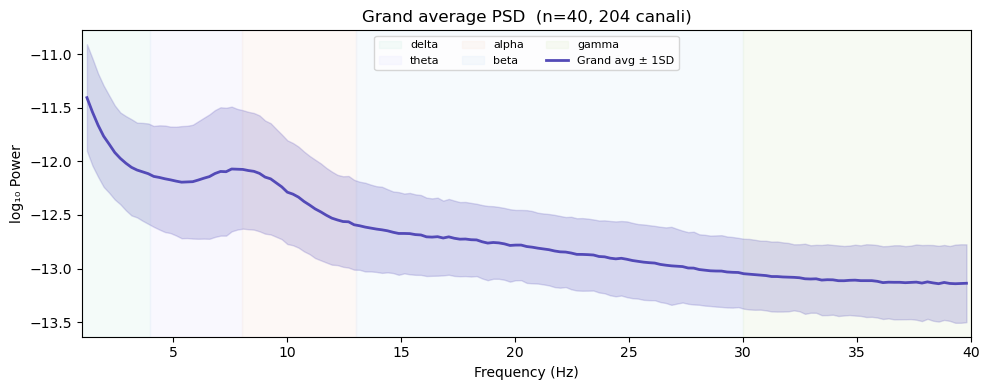

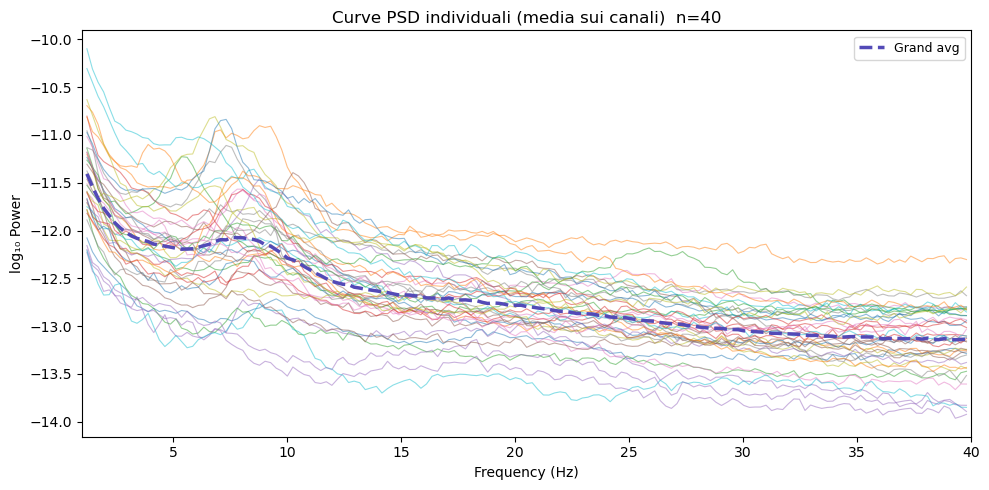

Salvati: QC_grand_avg_psd.pdf, QC_individual_psd_curves.pdf

✅ Tutto fatto! Output in: /Users/Altair93/Documents/TNFP/ONDA Lab/Projects/tutorial_EEG-NPSI/PSD/


In [13]:
grand_avg   = psd_log_matrix.mean(axis=(0, 1))
grand_std   = psd_log_matrix.mean(axis=1).std(axis=0)
band_colors = ["#E1F5EE","#EEEDFE","#FAECE7","#E6F1FB","#EAF3DE"]

# ── Plot 1: grand average ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for (bname, (blo, bhi)), col in zip(BANDS.items(), band_colors):
    ax.axvspan(blo, bhi, alpha=0.35, color=col, label=bname)
ax.fill_between(freq_axis, grand_avg - grand_std, grand_avg + grand_std,
                alpha=0.2, color="#534AB7")
ax.plot(freq_axis, grand_avg, color="#534AB7", lw=2, label="Grand avg ± 1SD")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("log₁₀ Power")
ax.set_title(f"Grand average PSD  (n={len(subject_ids)}, {len(channel_names)} canali)")
ax.legend(fontsize=8, ncol=3)
ax.set_xlim(FMIN, FMAX)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "QC_grand_avg_psd.pdf"))
plt.show()

# ── Plot 2: curve individuali ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(subject_ids)):
    ax.plot(freq_axis, psd_log_matrix[i].mean(axis=0), lw=0.8, alpha=0.5)
ax.plot(freq_axis, grand_avg, color="#534AB7", lw=2.5, ls="--", label="Grand avg")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("log₁₀ Power")
ax.set_title(f"Curve PSD individuali (media sui canali)  n={len(subject_ids)}")
ax.legend(fontsize=9)
ax.set_xlim(FMIN, FMAX)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "QC_individual_psd_curves.pdf"))
plt.show()

print("Salvati: QC_grand_avg_psd.pdf, QC_individual_psd_curves.pdf")
print(f"\n✅ Tutto fatto! Output in: {OUTPUT_DIR}")